In [1]:
import math


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [3]:
transform_base = transforms.Compose([
    transforms.Resize((224,224)),  # 고해상도로 맞추기
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='trainval', download=True, transform=transform_base
)


In [4]:
augmentations = {
    "ResizeCrop": transforms.RandomResizedCrop(224),
    "HorizontalFlip": transforms.RandomHorizontalFlip(p=1.0),
    "VerticalFlip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(30),
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    "Grayscale": transforms.RandomGrayscale(p=1.0),
    "GaussianBlur": transforms.GaussianBlur(kernel_size=5),
    "Cutout": transforms.RandomErasing(p=1.0),
    "Affine": transforms.RandomAffine(degrees=20, translate=(0.1,0.1), scale=(0.8,1.2)),
}


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


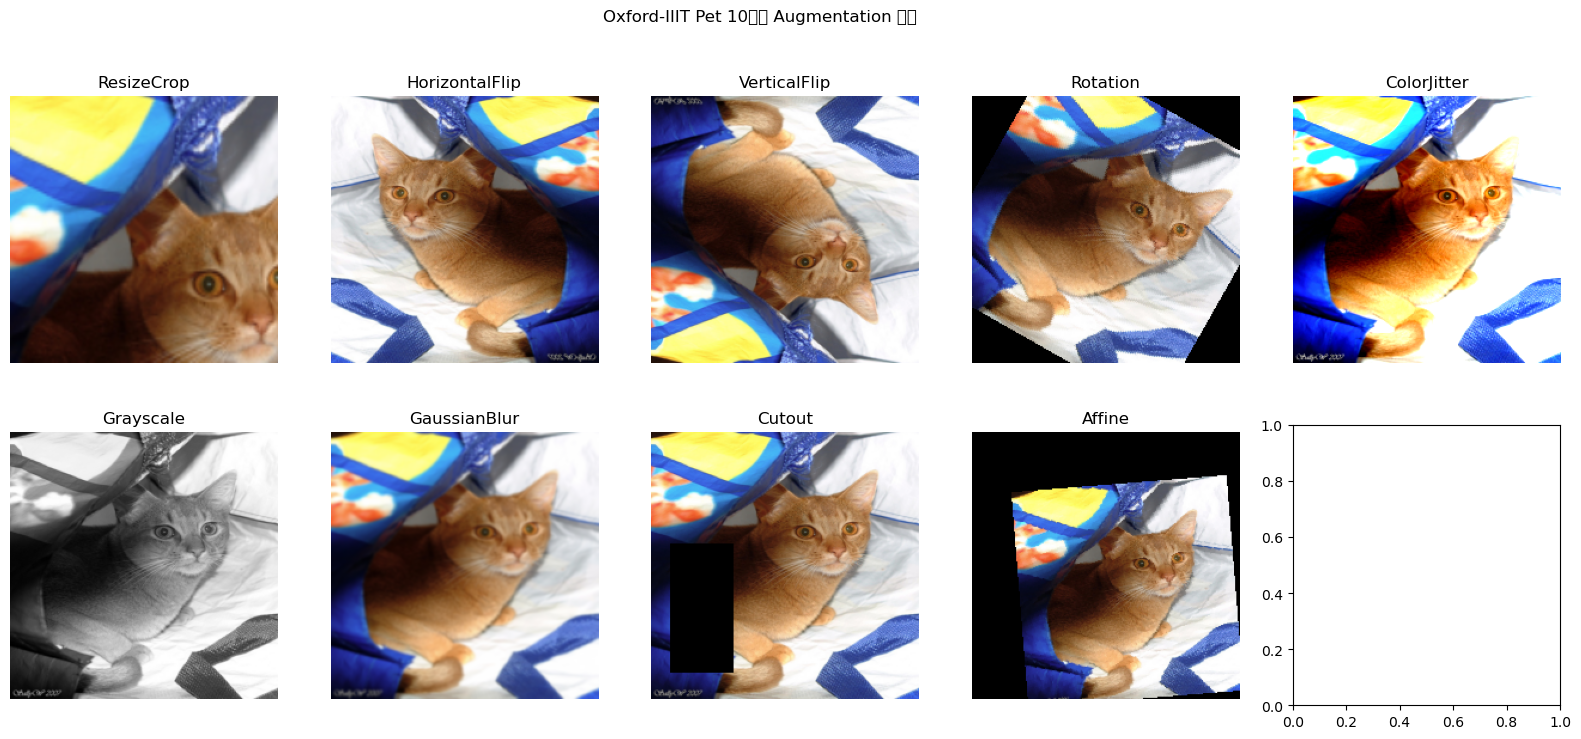

In [5]:
sample_img, _ = train_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(20,8))
for ax, (name, aug) in zip(axes.flatten(), augmentations.items()):
    img = aug(sample_img)
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # 정규화
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Oxford-IIIT Pet 10가지 Augmentation 예시")
plt.show()


In [6]:
augmentations = {
    "ResizeCrop": transforms.RandomResizedCrop(224),
    "HorizontalFlip": transforms.RandomHorizontalFlip(p=1.0),
    "VerticalFlip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(30),
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    "Grayscale": transforms.RandomGrayscale(p=1.0),
    "GaussianBlur": transforms.GaussianBlur(kernel_size=5),
    "Cutout": transforms.RandomErasing(p=1.0),
    "Affine": transforms.RandomAffine(degrees=20, translate=(0.1,0.1), scale=(0.8,1.2)),
    "Identity": transforms.Lambda(lambda x: x)  # 원본 그대로
}


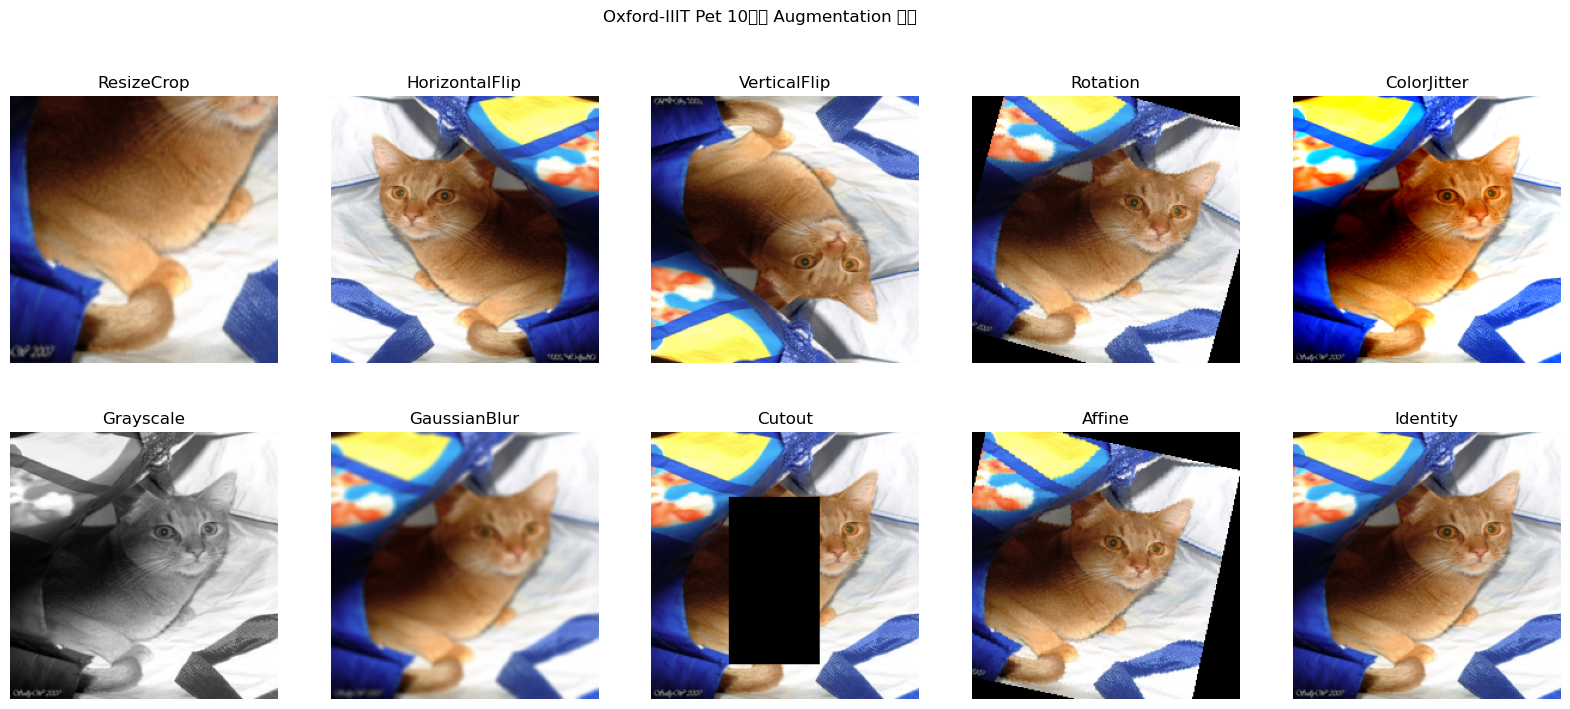

In [7]:
sample_img, _ = train_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(20,8))
for ax, (name, aug) in zip(axes.flatten(), augmentations.items()):
    img = aug(sample_img)
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Oxford-IIIT Pet 10가지 Augmentation 예시")
plt.show()


In [8]:
# CIFAR-10에서 샘플 이미지 두 장 가져오기
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1]

# Mixup 적용
mixed_img, _, _, lam = mixup_data(img1.unsqueeze(0), torch.tensor([label1]))
mixed_img = mixed_img.squeeze(0).permute(1,2,0).numpy()
mixed_img = (mixed_img - mixed_img.min()) / (mixed_img.max() - mixed_img.min())

# CutMix 적용
cutmix_img, _, _, lam = cutmix_data(torch.stack([img1, img2]), torch.tensor([label1, label2]))
cutmix_img = cutmix_img[0].permute(1,2,0).numpy()
cutmix_img = (cutmix_img - cutmix_img.min()) / (cutmix_img.max() - cutmix_img.min())

# 시각화
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img1.permute(1,2,0))
axes[0].set_title("원본 이미지 1")
axes[0].axis("off")

axes[1].imshow(mixed_img)
axes[1].set_title("Mixup 결과")
axes[1].axis("off")

axes[2].imshow(cutmix_img)
axes[2].set_title("CutMix 결과")
axes[2].axis("off")

plt.suptitle("Mixup vs CutMix 시각화")
plt.show()


NameError: name 'mixup_data' is not defined

In [ ]:
# 먼저 함수가 정의되어 있어야 한다. 이전에 NameError가 난 이유는 이 함수가 없었기 때문이다. 수정한다

In [9]:
def mixup_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size)
    cut_w = int(w * math.sqrt(1 - lam))
    cut_h = int(h * math.sqrt(1 - lam))
    cx, cy = torch.randint(w, (1,)), torch.randint(h, (1,))
    x1, y1 = max(cx - cut_w // 2, 0), max(cy - cut_h // 2, 0)
    x2, y2 = min(cx + cut_w // 2, w), min(cy + cut_h // 2, h)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y_a, y_b, lam


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

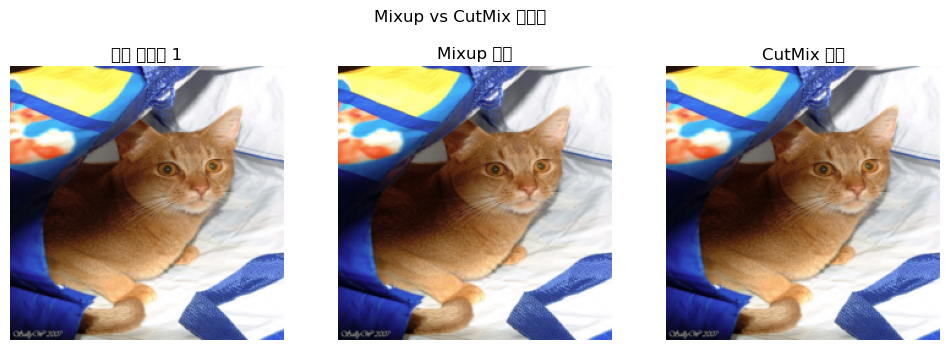

In [10]:
# 샘플 이미지 두 장 가져오기
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1]

# 배치 형태로 변환
imgs = torch.stack([img1, img2])
labels = torch.tensor([label1, label2])

# Mixup 적용
mixed_imgs, _, _, _ = mixup_data(imgs, labels)
mixed_img = mixed_imgs[0].permute(1,2,0).numpy()
mixed_img = (mixed_img - mixed_img.min()) / (mixed_img.max() - mixed_img.min())

# CutMix 적용
cutmix_imgs, _, _, _ = cutmix_data(imgs, labels)
cutmix_img = cutmix_imgs[0].permute(1,2,0).numpy()
cutmix_img = (cutmix_img - cutmix_img.min()) / (cutmix_img.max() - cutmix_img.min())

# 시각화
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img1.permute(1,2,0))
axes[0].set_title("원본 이미지 1")
axes[0].axis("off")

axes[1].imshow(mixed_img)
axes[1].set_title("Mixup 결과")
axes[1].axis("off")

axes[2].imshow(cutmix_img)
axes[2].set_title("CutMix 결과")
axes[2].axis("off")

plt.suptitle("Mixup vs CutMix 시각화")
plt.show()


In [11]:
#  NameError: name 'math' is not defined 에러가 난 이유는 math.sqrt를 사용했는데 math 모듈을 임포트하지 않았기 때문이다

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math   # ✅ 추가


In [ ]:
def mixup_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size)
    cut_w = int(w * math.sqrt(1 - lam))
    cut_h = int(h * math.sqrt(1 - lam))
    cx, cy = torch.randint(w, (1,)), torch.randint(h, (1,))
    x1, y1 = max(cx - cut_w // 2, 0), max(cy - cut_h // 2, 0)
    x2, y2 = min(cx + cut_w // 2, w), min(cy + cut_h // 2, h)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y_a, y_b, lam


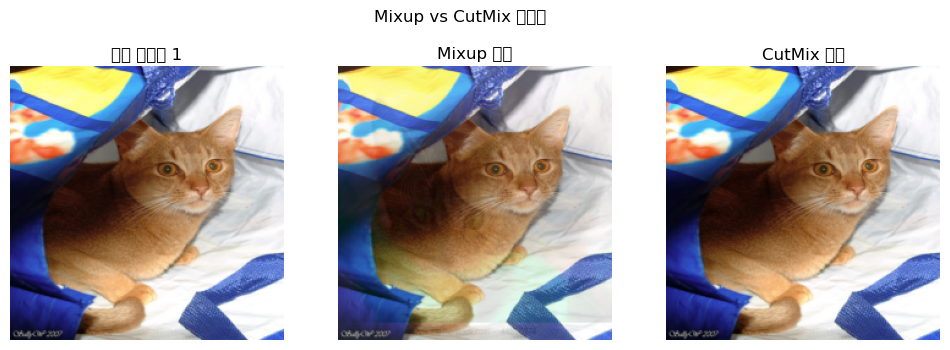

In [12]:
# 샘플 이미지 두 장 가져오기
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1]

imgs = torch.stack([img1, img2])
labels = torch.tensor([label1, label2])

# Mixup 적용
mixed_imgs, _, _, _ = mixup_data(imgs, labels)
mixed_img = mixed_imgs[0].permute(1,2,0).numpy()
mixed_img = (mixed_img - mixed_img.min()) / (mixed_img.max() - mixed_img.min())

# CutMix 적용
cutmix_imgs, _, _, _ = cutmix_data(imgs, labels)
cutmix_img = cutmix_imgs[0].permute(1,2,0).numpy()
cutmix_img = (cutmix_img - cutmix_img.min()) / (cutmix_img.max() - cutmix_img.min())

# 시각화
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img1.permute(1,2,0))
axes[0].set_title("원본 이미지 1")
axes[0].axis("off")

axes[1].imshow(mixed_img)
axes[1].set_title("Mixup 결과")
axes[1].axis("off")

axes[2].imshow(cutmix_img)
axes[2].set_title("CutMix 결과")
axes[2].axis("off")

plt.suptitle("Mixup vs CutMix 시각화")
plt.show()


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math   # ✅ 반드시 추가


In [14]:
def mixup_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size)
    cut_w = int(w * math.sqrt(1 - lam))
    cut_h = int(h * math.sqrt(1 - lam))
    cx, cy = torch.randint(w, (1,)), torch.randint(h, (1,))
    x1, y1 = max(cx - cut_w // 2, 0), max(cy - cut_h // 2, 0)
    x2, y2 = min(cx + cut_w // 2, w), min(cy + cut_h // 2, h)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y_a, y_b, lam


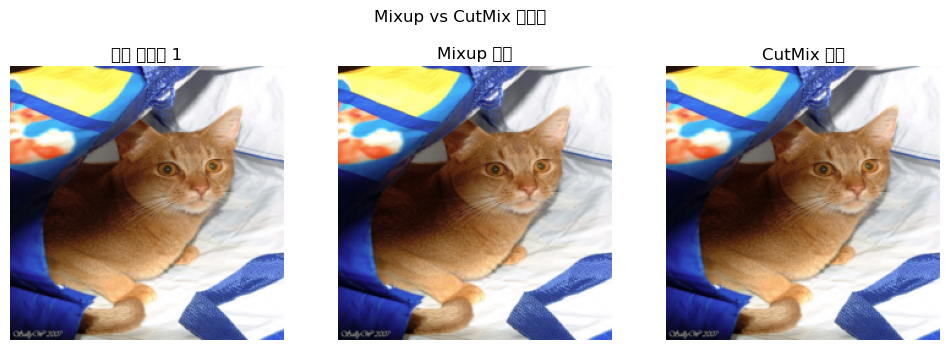

In [15]:
# 샘플 이미지 두 장 가져오기
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1]

imgs = torch.stack([img1, img2])
labels = torch.tensor([label1, label2])

# Mixup 적용
mixed_imgs, _, _, _ = mixup_data(imgs, labels)
mixed_img = mixed_imgs[0].permute(1,2,0).numpy()
mixed_img = (mixed_img - mixed_img.min()) / (mixed_img.max() - mixed_img.min())

# CutMix 적용
cutmix_imgs, _, _, _ = cutmix_data(imgs, labels)
cutmix_img = cutmix_imgs[0].permute(1,2,0).numpy()
cutmix_img = (cutmix_img - cutmix_img.min()) / (cutmix_img.max() - cutmix_img.min())

# 시각화
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img1.permute(1,2,0))
axes[0].set_title("원본 이미지 1")
axes[0].axis("off")

axes[1].imshow(mixed_img)
axes[1].set_title("Mixup 결과")
axes[1].axis("off")

axes[2].imshow(cutmix_img)
axes[2].set_title("CutMix 결과")
axes[2].axis("off")

plt.suptitle("Mixup vs CutMix 시각화")
plt.show()


In [16]:
acc_no_aug = train_model(train_loader, test_loader, augmentation=None)
acc_mixup = train_model(train_loader, test_loader, augmentation="mixup")
acc_cutmix = train_model(train_loader, test_loader, augmentation="cutmix")

epochs = range(1, 3)
plt.plot(epochs, acc_no_aug[1], 'r', label='No Augmentation')
plt.plot(epochs, acc_mixup[1], 'g', label='Mixup')
plt.plot(epochs, acc_cutmix[1], 'b', label='CutMix')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


NameError: name 'train_model' is not defined

In [17]:
# NameError: name 'train_model' is not defined 에러는 단순히 학습 함수(train_model)가 아직 정의되지 않은 상태에서 호출했기 때문이에요.

In [18]:
def train_model(train_loader, test_loader, augmentation=None, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_acc_list, test_acc_list = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            if augmentation == "mixup":
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            elif augmentation == "cutmix":
                images, y_a, y_b, lam = cutmix_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_acc = 100. * correct / total
        test_acc_list.append(test_acc)
        
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")
    
    return train_acc_list, test_acc_list


In [19]:
acc_no_aug = train_model(train_loader, test_loader, augmentation=None)
acc_mixup = train_model(train_loader, test_loader, augmentation="mixup")
acc_cutmix = train_model(train_loader, test_loader, augmentation="cutmix")

epochs = range(1, 3)
plt.plot(epochs, acc_no_aug[1], 'r', label='No Augmentation')
plt.plot(epochs, acc_mixup[1], 'g', label='Mixup')
plt.plot(epochs, acc_cutmix[1], 'b', label='CutMix')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


NameError: name 'train_loader' is not defined

In [20]:
#  NameError: name 'train_loader' is not defined 에러는 단순합니다 
데이터셋과 DataLoader를 정의하는 셀을 실행하지 않은 상태에서 학습 함수를 호출했기 때문이에요.

SyntaxError: invalid syntax (3101769855.py, line 2)

In [21]:
transform_base = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='trainval', download=True, transform=transform_base
)
test_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='test', download=True, transform=transform_base
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [22]:
def train_model(train_loader, test_loader, augmentation=None, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_acc_list, test_acc_list = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            if augmentation == "mixup":
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            elif augmentation == "cutmix":
                images, y_a, y_b, lam = cutmix_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_acc = 100. * correct / total
        test_acc_list.append(test_acc)
        
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")
    
    return train_acc_list, test_acc_list


In [23]:
acc_no_aug = train_model(train_loader, test_loader, augmentation=None)
acc_mixup = train_model(train_loader, test_loader, augmentation="mixup")
acc_cutmix = train_model(train_loader, test_loader, augmentation="cutmix")

epochs = range(1, 3)
plt.plot(epochs, acc_no_aug[1], 'r', label='No Augmentation')
plt.plot(epochs, acc_mixup[1], 'g', label='Mixup')
plt.plot(epochs, acc_cutmix[1], 'b', label='CutMix')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


NameError: name 'SimpleCNN' is not defined

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):  # CIFAR-10은 클래스 10개
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [25]:
acc_no_aug = train_model(train_loader, test_loader, augmentation=None)
acc_mixup = train_model(train_loader, test_loader, augmentation="mixup")
acc_cutmix = train_model(train_loader, test_loader, augmentation="cutmix")

epochs = range(1, 3)
plt.plot(epochs, acc_no_aug[1], 'r', label='No Augmentation')
plt.plot(epochs, acc_mixup[1], 'g', label='Mixup')
plt.plot(epochs, acc_cutmix[1], 'b', label='CutMix')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x200704 and 4096x128)

In [26]:
# **런타임 에러(RuntimeError: mat1 and mat2 shapes cannot be multiplied)**가 발생했네요.
이건 PyTorch에서 아주 흔한 문제인데, 원인은 CNN의 마지막 Linear 레이어 입력 크기와 실제 feature map 크기가 맞지 않아서입니다.

SyntaxError: invalid syntax (1623967068.py, line 2)

In [27]:
self.fc = nn.Sequential(
    nn.Linear(64*8*8, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)


NameError: name 'num_classes' is not defined

In [28]:
num_classes = 37   # Oxford Pet 데이터셋일 경우


In [29]:
self.fc = nn.Sequential(
    nn.Linear(64*8*8, 128),
    nn.ReLU(),
    nn.Linear(128, 37)   # Oxford Pet은 37 클래스
)


NameError: name 'self' is not defined

In [30]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=37):  # Oxford Pet은 클래스 37개
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((8,8))   # ✅ 항상 8x8로 맞춤
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
